In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

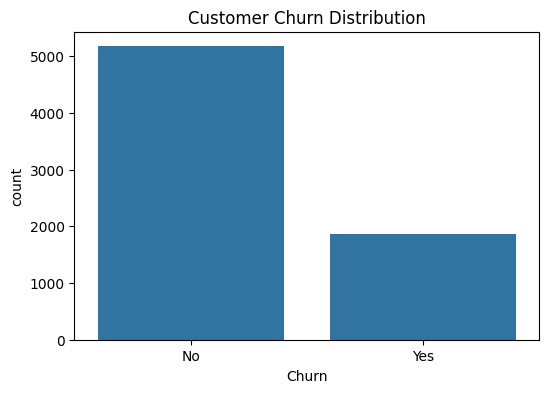

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

In [12]:
df['TotalCharges'].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [13]:
df['TotalCharges'].dtype

dtype('O')

In [14]:
df['TotalCharges'].str.strip().eq('').sum()

np.int64(11)

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [16]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [17]:
df[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [19]:
churn_rate = (df['Churn'].value_counts(normalize=True)['Yes']) * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.54%


In [20]:
pd.crosstab(df['gender'],df['Churn'])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


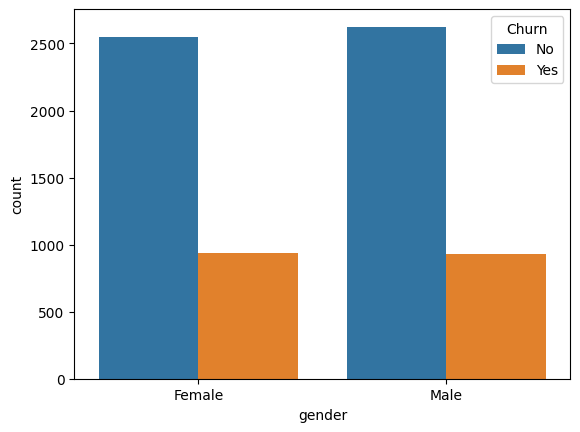

In [21]:
sns.countplot(x='gender',hue='Churn',data=df)

plt.show()

In [23]:
pd.crosstab(df['Contract'],df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


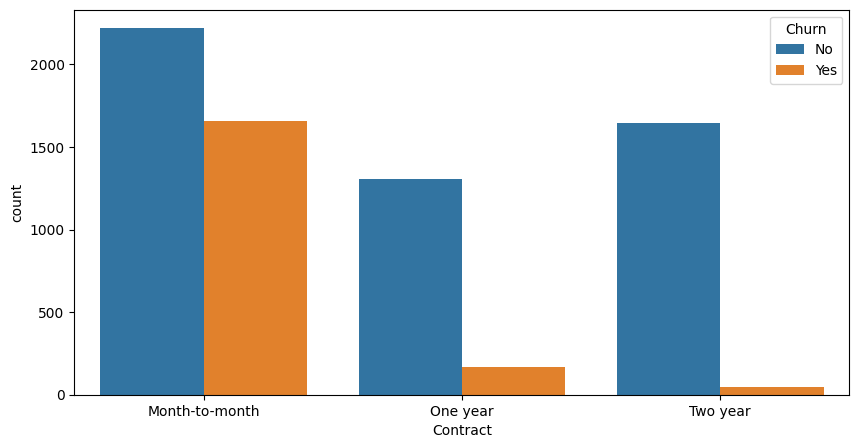

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(x='Contract',hue='Churn',data=df)

plt.show()

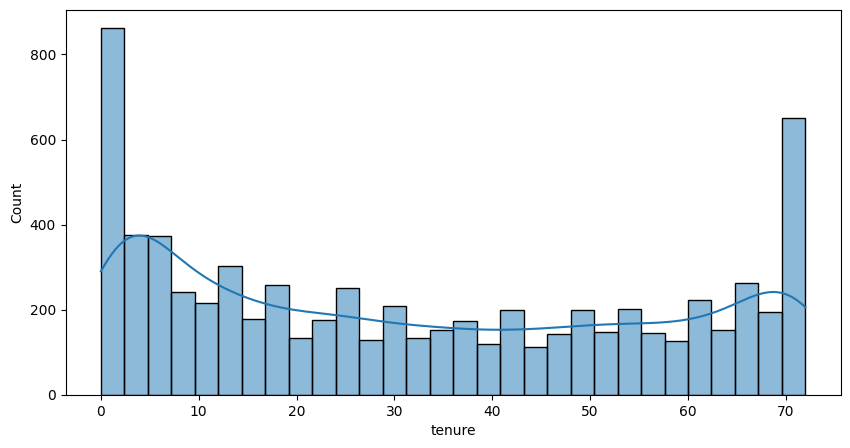

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(df['tenure'],bins=30,kde=True)

plt.show()

In [26]:
df.dropna(inplace=True)

In [27]:
df.shape

(7032, 21)

In [30]:
contract_churn = pd.crosstab(df['Contract'],df['Churn'],normalize='index') * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


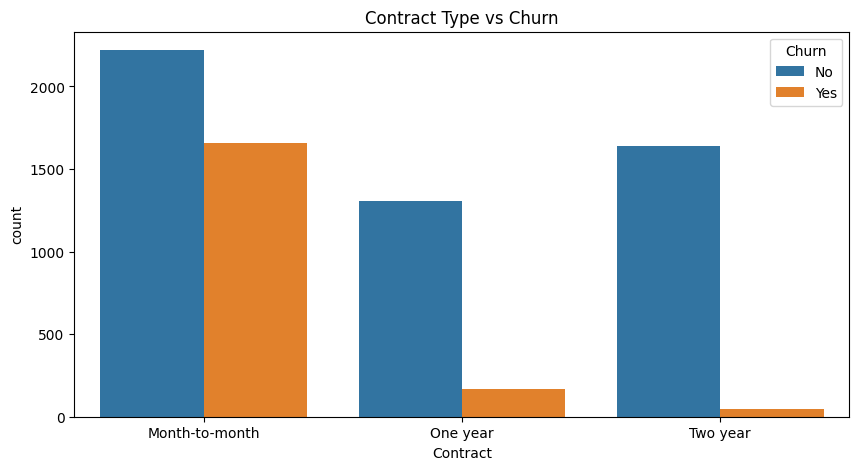

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(x='Contract',hue='Churn',data=df)

plt.title("Contract Type vs Churn")
plt.show()

In [32]:
internet_churn = pd.crosstab(df['InternetService'],df['Churn'],normalize='index') * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


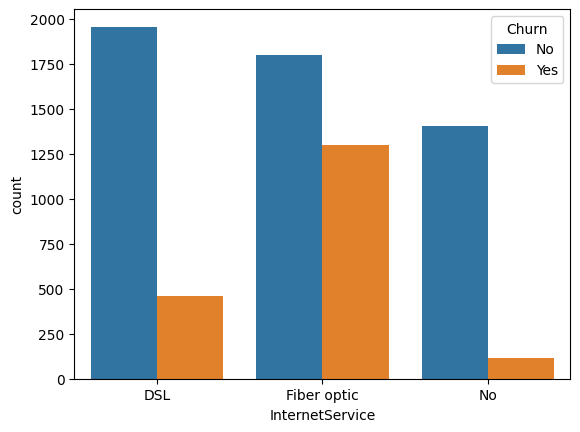

In [33]:

sns.countplot(x='InternetService',hue='Churn',data=df)

plt.show()

In [34]:
payment_churn = pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index') * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [35]:
paperless_churn = pd.crosstab(df['PaperlessBilling'],df['Churn'],normalize='index') * 100

paperless_churn

Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251


In [36]:
senior_churn = pd.crosstab(df['SeniorCitizen'],df['Churn'],normalize='index') * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [37]:
gender_churn = pd.crosstab(df['gender'],df['Churn'],normalize='index') * 100

gender_churn

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


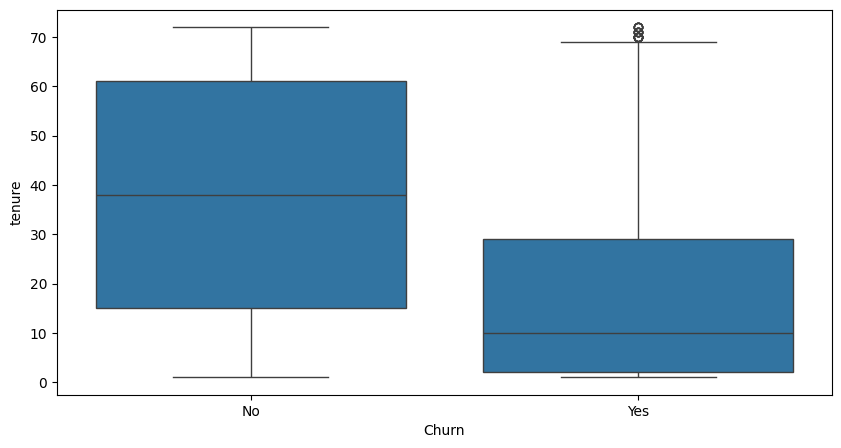

In [38]:
plt.figure(figsize=(10,5))

sns.boxplot(x='Churn',y='tenure',data=df)

plt.show()

In [39]:
# Drop customer identifier
df = df.drop('customerID', axis=1)

# Convert target variable
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [40]:
df['Churn'].value_counts()
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [41]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [42]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [43]:
print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [45]:
categorical_features = X.select_dtypes(include=['object']).columns

numeric_features = X.select_dtypes(exclude=['object']).columns

In [46]:
print("Categorical Features:")
print(categorical_features)

print("\nNumeric Features:")
print(numeric_features)

Categorical Features:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numeric Features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [49]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')


In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [52]:
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

In [53]:
rf_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [54]:
y_pred = rf_pipeline.predict(X_test)

In [55]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

print("Accuracy:",accuracy_score(y_test, y_pred))

print("Precision:",precision_score(y_test, y_pred))

print("Recall:",recall_score(y_test, y_pred))

print("F1:",f1_score(y_test, y_pred))

Accuracy: 0.7874911158493249
Precision: 0.6306620209059234
Recall: 0.4839572192513369
F1: 0.5476550680786687


In [56]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



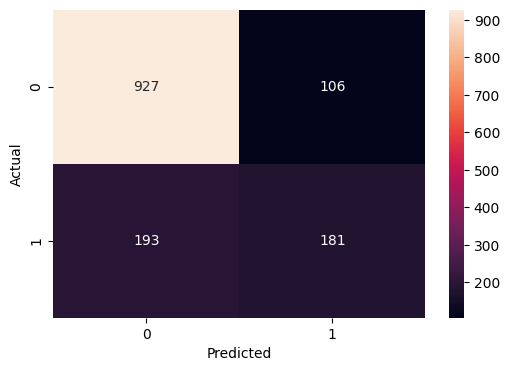

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [58]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [59]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [60]:
lr_pred = lr_pipeline.predict(X_test)

In [61]:
print(classification_report(y_test,lr_pred))

print("Accuracy:",accuracy_score(y_test, lr_pred))

print("Precision:",precision_score(y_test, lr_pred))

print("Recall:",recall_score(y_test, lr_pred))

print("F1:",f1_score(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Accuracy: 0.8038379530916845
Precision: 0.6484848484848484
Recall: 0.5721925133689839
F1: 0.6079545454545454


In [62]:
from sklearn.metrics import roc_auc_score

In [63]:
rf_prob = rf_pipeline.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(y_test,rf_prob)

print("RF AUC:", rf_auc)

RF AUC: 0.8136612120867004


In [64]:
lr_prob = lr_pipeline.predict_proba(X_test)[:,1]

lr_auc = roc_auc_score(y_test,lr_prob)

print("LR AUC:", lr_auc)

LR AUC: 0.8359290473207676


In [65]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

In [66]:
smote_lr_pipeline = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        (
            'model',
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [69]:
smote_lr_pipeline.fit(X_train,y_train)


,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

In [70]:
smote_lr_pred = smote_lr_pipeline.predict(X_test)

In [71]:
print(classification_report(y_test,smote_lr_pred))

print("Accuracy:",accuracy_score(y_test,smote_lr_pred))

print("Precision:",precision_score(y_test,smote_lr_pred))

print("Recall:",recall_score(y_test,smote_lr_pred))

print("F1:",f1_score(y_test,smote_lr_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

Accuracy: 0.7313432835820896
Precision: 0.49658703071672355
Recall: 0.7780748663101604
F1: 0.60625


In [72]:
smote_lr_prob = (smote_lr_pipeline.predict_proba(X_test)[:,1])
smote_lr_auc = roc_auc_score(y_test,smote_lr_prob)

print("SMOTE LR AUC:",smote_lr_auc)

SMOTE LR AUC: 0.8334001998229548


In [73]:
import joblib

joblib.dump(smote_lr_pipeline,"../models/churn_model.pkl")

['../models/churn_model.pkl']

In [74]:
import os

os.path.exists("../models/churn_model.pkl")

True

In [75]:
feature_names = (smote_lr_pipeline.named_steps['preprocessor'].get_feature_names_out())

feature_names[:10]

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Female', 'cat__gender_Male',
       'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No',
       'cat__Dependents_Yes'], dtype=object)

In [76]:
coefficients = (smote_lr_pipeline.named_steps['model'].coef_[0])

In [77]:
import pandas as pd

importance_df = pd.DataFrame({'Feature': feature_names,'Coefficient': coefficients})

importance_df = importance_df.sort_values(by='Coefficient',ascending=False)

importance_df.head(20)

,Feature,Coefficient
3,num__TotalCharges,0.762284
36,cat__Contract_Month-to-month,0.705156
16,cat__InternetService_Fiber optic,0.703589
35,cat__StreamingMovies_Yes,0.268079
43,cat__PaymentMethod_Electronic check,0.266989
18,cat__OnlineSecurity_No,0.262977
32,cat__StreamingTV_Yes,0.245637
27,cat__TechSupport_No,0.214176
14,cat__MultipleLines_Yes,0.142523
21,cat__OnlineBackup_No,0.097617


In [78]:
importance_df.tail(20)

,Feature,Coefficient
29,cat__TechSupport_Yes,-0.156111
42,cat__PaymentMethod_Credit card (automatic),-0.156322
30,cat__StreamingTV_No,-0.187572
20,cat__OnlineSecurity_Yes,-0.204911
33,cat__StreamingMovies_No,-0.210014
41,cat__PaymentMethod_Bank transfer (automatic),-0.212061
39,cat__PaperlessBilling_No,-0.251080
12,cat__MultipleLines_No,-0.265498
19,cat__OnlineSecurity_No internet service,-0.274311
28,cat__TechSupport_No internet service,-0.274311
